In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing


In [9]:
housing=fetch_california_housing()
X=pd.DataFrame(housing.data,columns=housing.feature_names)
y=housing.target
print("first 5 rows values of dataset:")
print(X.head())
 


first 5 rows values of dataset:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


In [10]:
print("missing values in dataset:")
print(X.isnull().sum())
print("statistical summary of dataset:")
print(X.describe())

missing values in dataset:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64
statistical summary of dataset:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude  
count  20640.000000  20640.000000  206

In [35]:
# ===================================================
# Helper function to train model and compute metrics
# ===================================================
def evaluate_model(X, y, title="Model"):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = np.mean(np.abs(y_test - y_pred))
    rmse = np.sqrt(mse)

    print(f"\n{title} Performance:")
    print("MSE :", mse)
    print("MAE :", mae)
    print("RMSE:", rmse)

    return model, y_test, y_pred, mse, mae, rmse


In [ ]:
# =====================================================
# 3. Simple Linear Regression (Feature: AveBedrms)
# =====================================================
X1 = X[["AveBedrms"]]
model1, y_test1, y_pred1, mse1, mae1, rmse1 = evaluate_model(
    X1, y, "Simple Regression (Bedrooms)"
)




Simple Regression (Bedrooms) Performance:
MSE : 1.3108875538359483
MAE : 0.9052326395429302
RMSE: 1.144939978267834


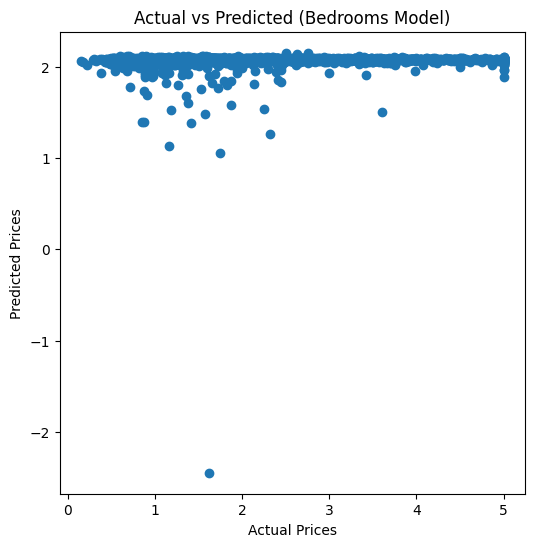

In [ ]:
# ==========================================
# 4. Plot actual vs predicted (simple model)
# ==========================================
plt.figure(figsize=(6,6))
plt.scatter(y_test1, y_pred1)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted (Bedrooms Model)")
plt.show()


In [39]:
mse1 = mean_squared_error(y_test1, y_pred1)
mae1 = np.mean(np.abs(y_test1 - y_pred1))
rmse1 = np.sqrt(mse1)

print("Simple Regression (AveBedrms)")
print("MSE:", mse1)
print("MAE:", mae1)
print("RMSE:", rmse1)


Simple Regression (AveBedrms)
MSE: 1.3108875538359483
MAE: 0.9052326395429302
RMSE: 1.144939978267834


In [41]:
# =====================================================
# 6. Simple Linear Regression (Feature: AveRooms)
# =====================================================
X2 = X[["AveRooms"]]
model2, y_test2, y_pred2, mse2, mae2, rmse2 = evaluate_model(
    X2, y, "Simple Regression (House Size / Rooms)"
)



Simple Regression (House Size / Rooms) Performance:
MSE : 1.2923314440807299
MAE : 0.8891490366373881
RMSE: 1.1368075668646518


In [43]:
# =====================================================
# 7. Compare error metrics between single features
# =====================================================
comparison_simple = pd.DataFrame({
    'Model': ['Bedrooms', 'Rooms'],
    'MSE': [mse1, mse2],
    'MAE': [mae1, mae2],
    'RMSE': [rmse1, rmse2]
})

print("\nSimple Regression Comparison:")
print(comparison_simple)



Simple Regression Comparison:
      Model       MSE       MAE      RMSE
0  Bedrooms  1.310888  0.905233  1.144940
1     Rooms  1.292331  0.889149  1.136808


In [45]:
# =====================================================
# 8. Multiple Regression (Two features)
# =====================================================
X_multi2 = X[["AveBedrms", "AveRooms"]]
model3, y_test3, y_pred3, mse3, mae3, rmse3 = evaluate_model(
    X_multi2, y, "Multiple Regression (2 Features)"
)



Multiple Regression (2 Features) Performance:
MSE : 1.1719222808390148
MAE : 0.8395605921061554
RMSE: 1.0825535925943874


In [49]:
# =====================================================
# 9. Multiple Regression (3+ features)
# =====================================================
X_multi3 = X[["AveBedrms", "AveRooms", "MedInc", "HouseAge"]]

model4, y_test4, y_pred4, mse4, mae4, rmse4 = evaluate_model(
    X_multi3, y, "Multiple Regression (All Features)"
)



Multiple Regression (All Features) Performance:
MSE : 0.6435680467793016
MAE : 0.5804193614410438
RMSE: 0.8022269297270577


In [50]:
# =====================================================
# 10. Compare multiple regression metrics
# =====================================================
comparison_multi = pd.DataFrame({
    'Model': ['Two Features', 'All Features'],
    'MSE': [mse3, mse4],
    'MAE': [mae3, mae4],
    'RMSE': [rmse3, rmse4]
})

print("\nMultiple Regression Comparison:")
print(comparison_multi)



Multiple Regression Comparison:
          Model       MSE       MAE      RMSE
0  Two Features  1.171922  0.839561  1.082554
1  All Features  0.643568  0.580419  0.802227


In [51]:
# =====================================================
# 11. Final comparison: Simple vs Multiple
# =====================================================
final_comparison = pd.DataFrame({
    'Model': ['Simple (Bedrooms)', 'Simple (Rooms)', 
              'Multiple (2 Features)', 'Multiple (All Features)'],
    'MSE': [mse1, mse2, mse3, mse4],
    'MAE': [mae1, mae2, mae3, mae4],
    'RMSE': [rmse1, rmse2, rmse3, rmse4]
})

print("\nFinal Comparison:")
print(final_comparison)



Final Comparison:
                     Model       MSE       MAE      RMSE
0        Simple (Bedrooms)  1.310888  0.905233  1.144940
1           Simple (Rooms)  1.292331  0.889149  1.136808
2    Multiple (2 Features)  1.171922  0.839561  1.082554
3  Multiple (All Features)  0.643568  0.580419  0.802227
